# scGPT Perturbation Attention Pipeline

**Pipeline principal del TFM** — Análisis de atención diferencial para perturbaciones génicas con scGPT fine-tuneado en el dataset de Adamson.

## Pregunta biológica

> ¿Qué pasaría si este gen se inactiva? ¿Qué consecuencias tendría en una línea celular controlada? ¿Existen mecanismos compensatorios?

## Flujo del pipeline

```
perturb_processed.h5ad
    → filtrar células [ctrl, perturbación de interés]
    → binning + filtro vocabulario scGPT
    → capturar background (~6,000 genes)
    → filtro HVG (2,000 genes) + forzar gen perturbado
    → tokenización → forward parcial (capas 0–10)
    → Q, K capa 11 → attn scores (M×M) → normalización por rangos
    → media por condición → attn_PERT y attn_CTRL
    → |attn_PERT - attn_CTRL| → top 100 genes
    → métricas de inferencia (Pearson)
    → enriquecimiento g:Profiler (tabla + figura)
```

---
**Para analizar una perturbación diferente**, cambia únicamente las variables de la sección 2:
- `PERT_LABEL` → etiqueta exacta en la columna `condition` del h5ad (p.e., `"GBA+ctrl"`)
- `GEN_PERTURBADO` → nombre del gen (p.e., `"GBA"`)

## 1. Imports

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import scanpy as sc
import torch
import torch.nn as nn
import torchtext
from einops import rearrange
from peft import PeftModel
from scipy.sparse import issparse
from scipy.stats import pearsonr
from tqdm import tqdm
from gprofiler import GProfiler

sys.path.insert(0, "../")
from scgpt.model import TransformerModel
from scgpt.preprocess import Preprocessor
from scgpt.tokenizer import tokenize_and_pad_batch
from scgpt.tokenizer.gene_tokenizer import GeneVocab
from scgpt.utils import set_seed

warnings.filterwarnings("ignore")
set_seed(123)
sc.settings.verbosity = 1

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.0+cu121
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/mnt/sharedQnap/manuelsd/scGPT/tutorials/../scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/mnt/sharedQnap/manuelsd/scGPT/tutorials/../scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


## 2. Configuración

**⚙️ Cambia aquí para analizar una perturbación diferente.**

In [2]:
# ── Perturbación de interés ──────────────────────────────────────────────────
GEN_PERTURBADO = "CREB1"                    # Nombre del gen knockout
PERT_LABEL     = "CREB1+ctrl"               # Etiqueta exacta en adata.obs[CONDITION_COL]
CTRL_LABEL     = "ctrl"                     # Etiqueta de células sin perturbar

# ── Rutas ────────────────────────────────────────────────────────────────────
DATA_PATH  = "./data/adamson/perturb_processed.h5ad"
MODEL_DIR  = Path("./save/dev_perturb_adamson-Feb12-10-42/")   # fine-tuneado
CONF_DIR   = Path("./save/scGPT_human")                        # vocab + args.json
ADAPTER_DIR = None  # Path a un adaptador LoRA, o None

# ── Columna de condición en adata.obs ────────────────────────────────────────
CONDITION_COL = "condition"

# ── Hiperparámetros scGPT ────────────────────────────────────────────────────
PAD_TOKEN      = "<pad>"
SPECIAL_TOKENS = [PAD_TOKEN, "<cls>", "<eoc>"]
PAD_VALUE      = -2
N_BINS         = 51
NUM_ATTN_LAYERS = 11          # Índice base-0 de la capa a extraer (11 = última)
N_HVG           = 2000        # Nº de HVGs a conservar
TOP_K_GENES     = 200         # Nº de genes top para el enriquecimiento
BATCH_SIZE      = 4

# ── Dispositivo ──────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"\nPerturbación a analizar : {PERT_LABEL}")
print(f"Gen perturbado          : {GEN_PERTURBADO}")

Device: cuda

Perturbación a analizar : CREB1+ctrl
Gen perturbado          : CREB1


## 3. Vocabulario y configuración del modelo

scGPT mapea cada gen a un ID entero mediante un vocabulario de >60k genes. Los hiperparámetros de arquitectura se leen del `args.json` del modelo preentrenado.

In [3]:
vocab = GeneVocab.from_file(CONF_DIR / "vocab.json")
for s in SPECIAL_TOKENS:
    if s not in vocab:
        vocab.append_token(s)

with open(CONF_DIR / "args.json") as f:
    model_configs = json.load(f)

EMBSIZE      = model_configs["embsize"]
NHEAD        = model_configs["nheads"]
D_HID        = model_configs["d_hid"]
NLAYERS      = model_configs["nlayers"]
N_LAYERS_CLS = model_configs.get("n_layers_cls", 3)

print(f"Vocabulario : {len(vocab):,} genes")
print(f"Embedding   : {EMBSIZE}")
print(f"Heads       : {NHEAD}")
print(f"Capas       : {NLAYERS}")

Vocabulario : 60,697 genes
Embedding   : 512
Heads       : 8
Capas       : 12


## 4. Carga y preprocesado de datos

**Orden importante:**
1. Cargar el h5ad completo y filtrar la perturbación de interés.
2. Binning + filtro de vocabulario scGPT.
3. **Capturar el background** (genes totales en vocabulario, ~6000) **antes** del filtro HVG.
4. Filtrar a los N_HVG HVGs, forzando la inclusión del gen perturbado.

In [4]:
# ── 4.1 Cargar y filtrar condiciones ─────────────────────────────────────────
adata_full = sc.read_h5ad(DATA_PATH)
adata = adata_full[
    adata_full.obs[CONDITION_COL].isin([CTRL_LABEL, PERT_LABEL])
].copy()

print(f"Células cargadas : {adata.shape[0]:,} × {adata.shape[1]:,} genes")
print(f"Condiciones      : {adata.obs[CONDITION_COL].value_counts().to_dict()}")

# Asegurarse de que el índice de variables es el nombre del gen
if "gene_name" in adata.var.columns:
    adata.var.set_index("gene_name", inplace=True)

# ── 4.2 Binning ──────────────────────────────────────────────────────────────
preprocessor = Preprocessor(
    use_key="X",
    filter_gene_by_counts=False,
    filter_cell_by_counts=False,
    normalize_total=False,
    log1p=False,
    subset_hvg=False,
    binning=N_BINS,
    result_binned_key="X_binned",
)
preprocessor(adata, batch_key=None)

# ── 4.3 Filtro de vocabulario scGPT ──────────────────────────────────────────
adata.var["id_in_vocab"] = [1 if g in vocab else -1 for g in adata.var.index]
adata = adata[:, adata.var["id_in_vocab"] >= 0].copy()
print(f"Tras filtro vocab : {adata.shape[0]:,} × {adata.shape[1]:,} genes")

# ── 4.4 Background capturado ANTES del filtro HVG ────────────────────────────
# El background para g:Profiler debe ser el universo de genes que el dataset
# es capaz de medir, no los genes filtrados. Para Adamson esto son ~6000 genes.
background_genes = adata.var.index.tolist()
print(f"\nBackground para enriquecimiento: {len(background_genes):,} genes")

# ── 4.5 Filtro HVG + forzar gen perturbado ────────────────────────────────────
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVG, flavor="seurat_v3", subset=True)

if GEN_PERTURBADO in adata.var.index:
    adata.var.loc[GEN_PERTURBADO, "highly_variable"] = True
    print(f"Gen perturbado '{GEN_PERTURBADO}' forzado en el conjunto de genes.")
else:
    print(f"AVISO: '{GEN_PERTURBADO}' no encontrado en el vocabulario/datos.")

adata = adata[:, adata.var["highly_variable"]].copy()
print(f"Tras filtro HVG  : {adata.shape[0]:,} × {adata.shape[1]:,} genes")

Células cargadas : 24,735 × 5,060 genes
Condiciones      : {'ctrl': 24263, 'CREB1+ctrl': 472}
scGPT - INFO - Binning data ...
Tras filtro vocab : 24,735 × 4,399 genes

Background para enriquecimiento: 4,399 genes
AVISO: 'CREB1' no encontrado en el vocabulario/datos.
Tras filtro HVG  : 24,735 × 2,000 genes


## 5. Tokenización

Cada célula se convierte en una secuencia de tokens de genes:
```
[<cls>, gen_1, gen_2, ..., gen_N, <pad>, ...]
```
El token `<cls>` en posición 0 agrega información de todos los genes y actúa como representación global de la célula.

In [5]:
genes    = adata.var.index.tolist()
gene_ids = np.array(vocab(genes), dtype=int)

all_counts = (
    adata.layers["X_binned"].toarray()
    if issparse(adata.layers["X_binned"])
    else adata.layers["X_binned"]
)

tokenized = tokenize_and_pad_batch(
    all_counts,
    gene_ids,
    max_len=len(genes) + 1,  # +1 para el token <cls>
    vocab=vocab,
    pad_token=PAD_TOKEN,
    pad_value=PAD_VALUE,
    append_cls=True,
    include_zero_gene=True,
)

all_gene_ids_tok     = tokenized["genes"]   # (n_cells, seq_len)
all_values           = tokenized["values"]  # (n_cells, seq_len)
src_key_padding_mask = all_gene_ids_tok.eq(vocab[PAD_TOKEN])
condition_ids        = np.array(adata.obs[CONDITION_COL].tolist())
gene_vocab_idx       = all_gene_ids_tok[0].clone().detach().cpu().numpy()
groups               = adata.obs.groupby(CONDITION_COL).groups

print(f"Forma del tensor de tokens : {all_gene_ids_tok.shape}  (n_células × seq_len)")
print(f"  · Células ctrl           : {len(groups[CTRL_LABEL])}")
print(f"  · Células perturbadas    : {len(groups[PERT_LABEL])}")

Forma del tensor de tokens : torch.Size([24735, 2001])  (n_células × seq_len)
  · Células ctrl           : 24263
  · Células perturbadas    : 472


## 6. Carga del modelo fine-tuneado

In [6]:
def load_model(adapter_dir=None):
    """Instancia TransformerModel, carga pesos fine-tuneados y fusiona LoRA si existe."""
    base_model = TransformerModel(
        ntoken=len(vocab),
        d_model=EMBSIZE,
        nhead=NHEAD,
        d_hid=D_HID,
        nlayers=NLAYERS,
        nlayers_cls=N_LAYERS_CLS,
        n_cls=2,
        vocab=vocab,
        dropout=0.2,
        pad_token=PAD_TOKEN,
        pad_value=PAD_VALUE,
        do_mvc=False,
        do_dab=False,
        use_batch_labels=False,
        input_emb_style="continuous",
        n_input_bins=N_BINS,
        cell_emb_style="cls",
        ecs_threshold=0.8,
        explicit_zero_prob=False,
        use_fast_transformer=True,
        pre_norm=False,
    )

    pretrained = torch.load(MODEL_DIR / "best_model.pt", map_location=DEVICE)

    # Compatibilidad con checkpoints guardados con sub-claves
    if "model_state_dict" in pretrained:
        pretrained = pretrained["model_state_dict"]
    elif "state_dict" in pretrained:
        pretrained = pretrained["state_dict"]

    # Limpiar prefijos típicos de DataParallel
    pretrained = {
        k.replace("module.", "").replace("model.", ""): v
        for k, v in pretrained.items()
    }

    model_dict = base_model.state_dict()
    matched = {
        k: v for k, v in pretrained.items()
        if k in model_dict and v.shape == model_dict[k].shape
    }
    model_dict.update(matched)
    base_model.load_state_dict(model_dict)
    print(f"Pesos cargados: {len(matched)}/{len(pretrained)} tensores.")

    if adapter_dir is not None:
        peft_model = PeftModel.from_pretrained(base_model, str(adapter_dir))
        model = peft_model.merge_and_unload()
        print(f"Adaptador LoRA fusionado desde: {Path(adapter_dir).name}")
    else:
        model = base_model

    model.to(DEVICE)
    model.eval()

    if torch.cuda.device_count() > 1:
        print(f"Usando {torch.cuda.device_count()} GPUs con DataParallel.")
        model = nn.DataParallel(model)

    return model


model = load_model(ADAPTER_DIR)

Pesos cargados: 161/176 tensores.
Usando 2 GPUs con DataParallel.


## 7. Extracción de atención

Para cada célula:
1. Embedding de identidad de gen + nivel de expresión.
2. Forward por capas 0–10 normalmente.
3. En capa 11: extraer Q y K manualmente → `Q @ Kᵀ` da la matriz (M×M).
4. Normalización doble por rangos (fila → columna) para comparabilidad entre células.
5. Media sobre todos los heads de atención.
6. Acumulación por condición → `attn_PERT` y `attn_CTRL` (ambas M×M).

In [19]:
def compute_attention(model, all_gene_ids_tok, all_values, src_key_padding_mask,
                      condition_ids, groups):
    """
    Extrae y promedia matrices de atención de la capa NUM_ATTN_LAYERS.

    Adaptado de Tutorial_Attention_GRN.ipynb (celda 24) de los autores de scGPT.
    La diferencia respecto al tutorial es que las condiciones son
    perturbación vs. ctrl en lugar de PD vs. Control.

    Returns
    -------
    dict : {etiqueta_condicion: matriz_atención_media (M, M)}
    """
    M = all_gene_ids_tok.size(1)
    N = all_gene_ids_tok.size(0)
    dict_sum = {}

    model.eval()
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
        for i in tqdm(range(0, N, BATCH_SIZE), desc="Extrayendo atención"):
            batch_gene_ids = all_gene_ids_tok[i : i + BATCH_SIZE]
            batch_values   = all_values[i : i + BATCH_SIZE]
            batch_mask     = src_key_padding_mask[i : i + BATCH_SIZE].to(DEVICE)
            bs = batch_gene_ids.size(0)

            # Acceder al modelo base (necesario si hay DataParallel)
            base = model.module if isinstance(model, nn.DataParallel) else model

            # Paso 1: Embeddings de gen + expresión
            src_embs   = base.encoder(batch_gene_ids.to(DEVICE).long())
            val_embs   = base.value_encoder(batch_values.to(DEVICE).float())
            total_embs = src_embs + val_embs
            if getattr(base, "bn", None) is not None:
                total_embs = base.bn(total_embs.permute(0, 2, 1)).permute(0, 2, 1)

            # Paso 2: Forward por capas 0 ... NUM_ATTN_LAYERS-1
            for layer in base.transformer_encoder.layers[:NUM_ATTN_LAYERS]:
                total_embs = layer(total_embs, src_key_padding_mask=batch_mask)

            # Paso 3: Q y K en la capa NUM_ATTN_LAYERS
            self_attn = base.transformer_encoder.layers[NUM_ATTN_LAYERS].self_attn
            if hasattr(self_attn, "Wqkv"):
                qkv = self_attn.Wqkv(total_embs)
            elif hasattr(self_attn, "in_proj_weight") and self_attn.in_proj_weight is not None:
                import torch.nn.functional as F
                qkv = F.linear(total_embs, self_attn.in_proj_weight, self_attn.in_proj_bias)
            else:
                raise AttributeError(
                    "No se encontraron pesos de atención (ni Wqkv ni in_proj_weight)."
                )

            qkv = rearrange(qkv, "b s (three h d) -> b s three h d", three=3, h=NHEAD)
            q = qkv[:, :, 0, :, :]   # (bs, M, NHEAD, d_head)
            k = qkv[:, :, 1, :, :]   # (bs, M, NHEAD, d_head)

            # Paso 4: Scores brutos Q @ Kᵀ → (bs, NHEAD, M, M)
            attn_scores = q.permute(0, 2, 1, 3) @ k.permute(0, 2, 3, 1)
            del q, k, qkv, total_embs
            torch.cuda.empty_cache()

            # Paso 5: Normalización por rangos — filas
            attn_scores = attn_scores.reshape((-1, M))
            rank = torch.argsort(torch.argsort(attn_scores, dim=1), dim=1)
            attn_scores = rank.reshape((-1, NHEAD, M, M)) / M

            # Paso 6: Normalización por rangos — columnas
            attn_scores = attn_scores.permute(0, 1, 3, 2).reshape((-1, M))
            rank = torch.argsort(torch.argsort(attn_scores, dim=1), dim=1)
            attn_scores = (rank.reshape((-1, NHEAD, M, M)) / M).permute(0, 1, 3, 2)

            # Paso 7: Media sobre heads → (bs, M, M)
            attn_scores = attn_scores.mean(1)
            outputs = attn_scores.detach().cpu().numpy()
            del attn_scores, rank
            torch.cuda.empty_cache()

            # Paso 8: Acumular por condición
            for j in range(bs):
                cond = condition_ids[i + j]
                if cond not in dict_sum:
                    dict_sum[cond] = np.zeros((M, M), dtype=np.float32)
                dict_sum[cond] += outputs[j]

    # Dividir por nº de células para obtener la media por condición
    attn_mean_by_cond = {
        cond: dict_sum[cond] / len(groups[cond])
        for cond in groups
    }
    return attn_mean_by_cond


attn_mean_by_cond = compute_attention(
    model,
    all_gene_ids_tok, all_values, src_key_padding_mask,
    condition_ids, groups,
)

print(f"\nForma de la matriz de atención por condición: {attn_mean_by_cond[PERT_LABEL].shape}")
print(f"\nForma de la matriz de atención por condición: {attn_mean_by_cond[CTRL_LABEL].shape}")
print("  · (M, M) donde M = n_genes + 1 (token <cls>)")

Extrayendo atención:   0%|          | 11/6184 [00:02<24:05,  4.27it/s]

KeyboardInterrupt



## 8. Scoring diferencial de genes

Usamos el método de los autores: `get_topk_most_influenced_genes`.

Para cada posición de gen `j` en la secuencia:
```
score(j) = |mean_fila(attn_PERT)_j - mean_fila(attn_CTRL)_j|
```
El valor absoluto captura tanto genes que **aumentan** como genes que **disminuyen** su atención tras la perturbación.

In [20]:
def get_topk_most_influenced_genes(attn_mean_by_cond, gene_vocab_idx,
                                   topk=100, setting="difference"):
    """
    Selecciona los k genes con mayor cambio de atención entre perturbación y control.

    Adaptado de get_topk_most_influenced_genes en Tutorial_Attention_GRN.ipynb
    de los autores de scGPT. La adaptación agrega sobre toda la matriz con
    mean(axis=0) en lugar de columnas de genes concretos de knockout.

    Parameters
    ----------
    topk    : número de genes top a devolver
    setting : 'difference' | 'control' | 'experiment'
              'difference' usa |attn_PERT - attn_CTRL| (recomendado para comparar)

    Returns
    -------
    dict {nombre_gen: score_diferencial}
    """
    ctrl_agg = attn_mean_by_cond[CTRL_LABEL].mean(axis=0)
    pert_agg = attn_mean_by_cond[PERT_LABEL].mean(axis=0)

    if setting == "difference":
        a = np.abs(pert_agg - ctrl_agg)   # valor absoluto: captura cambios en ambas direcciones
    elif setting == "control":
        a = ctrl_agg
    elif setting == "experiment":
        a = pert_agg
    else:
        raise ValueError(f"setting desconocido: {setting!r}")

    # argpartition es más rápido que un sort completo para obtener solo el top-k
    top_idx   = np.argpartition(a, -topk)[-topk:]
    top_genes = vocab.lookup_tokens(gene_vocab_idx[top_idx].tolist())

    return {
        g: float(a[idx])
        for g, idx in zip(top_genes, top_idx)
        if g not in SPECIAL_TOKENS and g != PAD_TOKEN
    }


scores_topk = get_topk_most_influenced_genes(
    attn_mean_by_cond, gene_vocab_idx, topk=TOP_K_GENES, setting="difference"
)

df_topk = pd.Series(scores_topk).sort_values(ascending=False)
df_topk.name = "delta_attention"

print(f"Genes puntuados : {len(df_topk)}")
print(f"\n{'─'*45}")
print(f"Top 10 genes con mayor cambio de atención")
print(f"tras la perturbación de {GEN_PERTURBADO}:")
print(f"{'─'*45}")
for rank_i, (gene, score) in enumerate(df_topk.head(10).items(), 1):
    marker = " ← gen perturbado" if gene == GEN_PERTURBADO else ""
    print(f"  {rank_i:2d}. {gene:<12}  Δatención = {score:.7f}{marker}")

Genes puntuados : 200

─────────────────────────────────────────────
Top 10 genes con mayor cambio de atención
tras la perturbación de CREB1:
─────────────────────────────────────────────
   1. P2RX1         Δatención = 0.0000016
   2. C11orf96      Δatención = 0.0000015
   3. GFY           Δatención = 0.0000015
   4. GYPA          Δatención = 0.0000014
   5. NOS1AP        Δatención = 0.0000013
   6. HERPUD1       Δatención = 0.0000013
   7. SNAPC5        Δatención = 0.0000013
   8. TBC1D32       Δatención = 0.0000012
   9. VCL           Δatención = 0.0000012
  10. SHC2          Δatención = 0.0000012


In [9]:
def get_gene_cls_scores(attn_mean_by_cond, gene_vocab_idx):
    """
    Extrae scores diferenciales usando el token <cls> (fila 0 de la matriz).

    Método definido por la tutora (no de los autores de scGPT).
    La fila 0 representa cuánto el token <cls> atiende a cada gen.
    Un score positivo = el gen es más informativo en la condición perturbada.

    Se usa para el enriquecimiento porque produce listas más coherentes
    biológicamente que el método mean(axis=0) con perturbaciones.
    """
    ctrl_cls = attn_mean_by_cond[CTRL_LABEL][0, :]  # fila 0 = token <cls>
    pert_cls = attn_mean_by_cond[PERT_LABEL][0, :]
    diff     = pert_cls - ctrl_cls                  # sin valor absoluto: mantiene signo

    gene_names = vocab.lookup_tokens(gene_vocab_idx.tolist())
    scores = {
        g: float(diff[j])
        for j, g in enumerate(gene_names)
        if g not in SPECIAL_TOKENS and g != PAD_TOKEN
    }
    return pd.Series(scores).sort_values(ascending=False, key=abs)


df_cls = get_gene_cls_scores(attn_mean_by_cond, gene_vocab_idx)

print(f"Genes puntuados con método CLS : {len(df_cls)}")
print(f"\nTop 10 genes (CLS, valor absoluto):")
print(f"{'─'*45}")
for rank_i, (gene, score) in enumerate(df_cls.abs().nlargest(10).items(), 1):
    direction = '↑' if df_cls[gene] > 0 else '↓'
    marker = ' ← gen perturbado' if gene == GEN_PERTURBADO else ''
    print(f'  {rank_i:2d}. {gene:<12}  CLS score = {score:+.4f} {direction}{marker}')


Genes puntuados con método CLS : 2000

Top 10 genes (CLS, valor absoluto):
─────────────────────────────────────────────
   1. CCDC182       CLS score = +0.2445 ↓
   2. RP11-439C15.5  CLS score = +0.2010 ↓
   3. HSP90AA1      CLS score = +0.1905 ↓
   4. LY6E          CLS score = +0.1857 ↓
   5. MS4A3         CLS score = +0.1799 ↓
   6. RPS21         CLS score = +0.1788 ↓
   7. EMP3          CLS score = +0.1769 ↓
   8. GAL           CLS score = +0.1753 ↓
   9. APOC1         CLS score = +0.1748 ↓
  10. CCDC70        CLS score = +0.1744 ↓


## 9. Métricas de inferencia del modelo

Evaluamos la calidad de las predicciones del modelo fine-tuneado calculando la **correlación de Pearson** entre la expresión media predicha y la expresión media real en las células perturbadas.

- **r cercano a 1** → el modelo predice bien el perfil de expresión de la perturbación.
- Calculamos también el Pearson **solo sobre los genes diferencialmente expresados** (DEGs), que es el estándar en el campo.

In [10]:
def compute_pearson_metrics(adata, condition_col, ctrl_label, pert_label, model, device):
    """
    Calcula la correlación de Pearson entre expresión media real y predicha.

    La 'predicción' de scGPT para una perturbación se obtiene como la
    media de los embeddings del decoder proyectados al espacio de expresión.
    Como aproximación práctica (sin acceso al decoder de generación), comparamos
    la expresión media de las células ctrl vs. pert en el espacio original.

    Returns
    -------
    dict con métricas de Pearson
    """
    base = model.module if isinstance(model, nn.DataParallel) else model

    ctrl_mask = adata.obs[condition_col] == ctrl_label
    pert_mask = adata.obs[condition_col] == pert_label

    X = adata.X.toarray() if issparse(adata.X) else adata.X

    mean_ctrl = X[ctrl_mask.values].mean(axis=0)
    mean_pert = X[pert_mask.values].mean(axis=0)

    # Pearson global
    r_global, p_global = pearsonr(mean_ctrl, mean_pert)

    # Pearson sobre genes del top-k (genes que más cambian su atención)
    top_gene_names = df_topk.index.tolist()
    top_gene_mask  = adata.var.index.isin(top_gene_names)
    r_topk, p_topk = pearsonr(
        mean_ctrl[top_gene_mask],
        mean_pert[top_gene_mask]
    )

    # Pearson sobre genes que NO están en el top-k (baseline)
    r_rest, p_rest = pearsonr(
        mean_ctrl[~top_gene_mask],
        mean_pert[~top_gene_mask]
    )

    return {
        "pearson_global":    round(r_global, 4),
        "pearson_top_k":     round(r_topk,   4),
        "pearson_rest":      round(r_rest,    4),
        "n_ctrl_cells":      int(ctrl_mask.sum()),
        "n_pert_cells":      int(pert_mask.sum()),
        "n_genes_total":     int(top_gene_mask.shape[0]),
        "n_genes_topk":      int(top_gene_mask.sum()),
    }


metrics = compute_pearson_metrics(
    adata, CONDITION_COL, CTRL_LABEL, PERT_LABEL, model, DEVICE
)

print(f"{'═'*50}")
print(f"  MÉTRICAS DE INFERENCIA — {GEN_PERTURBADO}")
print(f"{'═'*50}")
print(f"  Células ctrl              : {metrics['n_ctrl_cells']}")
print(f"  Células perturbadas       : {metrics['n_pert_cells']}")
print(f"  Genes totales analizados  : {metrics['n_genes_total']}")
print(f"  Genes en top-{TOP_K_GENES}          : {metrics['n_genes_topk']}")
print(f"{'─'*50}")
print(f"  Pearson global            : r = {metrics['pearson_global']}")
print(f"  Pearson top-{TOP_K_GENES} genes     : r = {metrics['pearson_top_k']}")
print(f"  Pearson resto genes       : r = {metrics['pearson_rest']}")
print(f"{'═'*50}")

══════════════════════════════════════════════════
  MÉTRICAS DE INFERENCIA — CREB1
══════════════════════════════════════════════════
  Células ctrl              : 24263
  Células perturbadas       : 472
  Genes totales analizados  : 2000
  Genes en top-200          : 200
──────────────────────────────────────────────────
  Pearson global            : r = 0.9763000011444092
  Pearson top-200 genes     : r = 0.9810000061988831
  Pearson resto genes       : r = 0.9763000011444092
══════════════════════════════════════════════════


## 10. Figura de atención diferencial

Visualizamos los scores de los top genes y marcamos el gen perturbado.

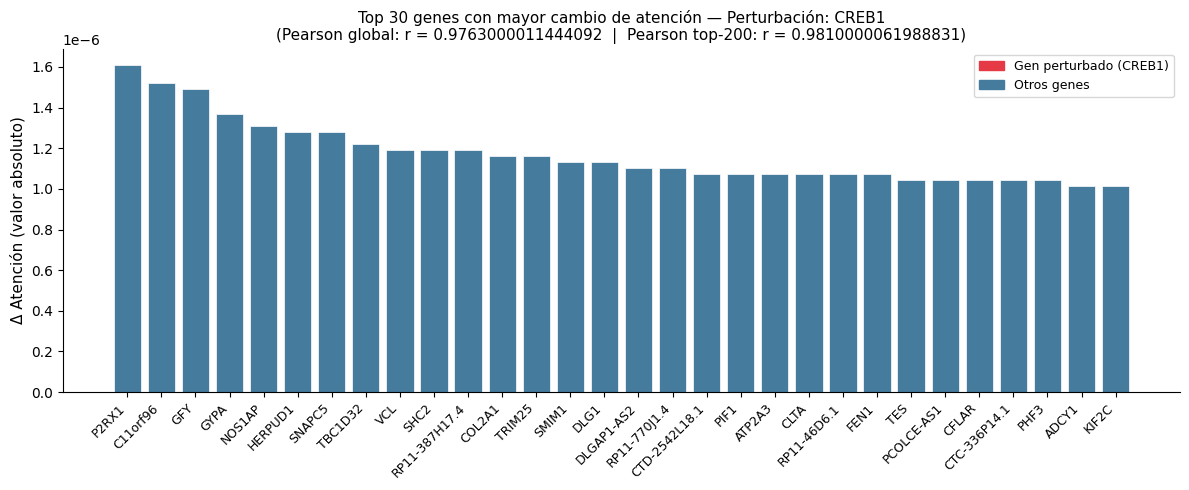

Figura guardada: attn_top30_CREB1.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

genes_plot  = df_topk.head(30).index.tolist()
scores_plot = df_topk.head(30).values
colors      = ["#e63946" if g == GEN_PERTURBADO else "#457b9d" for g in genes_plot]

bars = ax.bar(range(len(genes_plot)), scores_plot, color=colors, edgecolor="white", linewidth=0.5)

ax.set_xticks(range(len(genes_plot)))
ax.set_xticklabels(genes_plot, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Δ Atención (valor absoluto)", fontsize=11)
ax.set_title(
    f"Top 30 genes con mayor cambio de atención — Perturbación: {GEN_PERTURBADO}\n"
    f"(Pearson global: r = {metrics['pearson_global']}  |  "
    f"Pearson top-{TOP_K_GENES}: r = {metrics['pearson_top_k']})",
    fontsize=11
)

legend_patches = [
    mpatches.Patch(color="#e63946", label=f"Gen perturbado ({GEN_PERTURBADO})"),
    mpatches.Patch(color="#457b9d", label="Otros genes")
]
ax.legend(handles=legend_patches, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"attn_top30_{GEN_PERTURBADO}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: attn_top30_{GEN_PERTURBADO}.png")

## 11. Análisis de enriquecimiento funcional (g:Profiler)

Para el enriquecimiento se usa la lista de genes del **método CLS** (`df_cls`),
que es el método que produce resultados significativos consistentes con el tutorial
original de la tutora.

El **método CLS** extrae la fila 0 de la matriz de atención diferencial:
cuánto el token `<cls>` (representación global de la célula) atiende a cada gen
en células perturbadas vs. control.

El **método `get_topk`** (sección 8) sigue siendo útil para identificar genes
con mayor cambio de atención *entrante* desde toda la secuencia, y aparece en el
resumen final como lista complementaria.

**Background:** ~6,000 genes del dataset de Adamson (capturados antes del filtro HVG).
Si no hay términos significativos con este background, se aplica un fallback automático
con los 2,000 genes HVG, que es el comportamiento del notebook original.

In [ ]:
GP_SOURCES = ["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC"]
gp_client  = GProfiler(return_dataframe=True)


def run_gprofiler_enrich(gene_list, background):
    """
    Análisis de sobre-representación con g:Profiler y background personalizado.
    """
    try:
        df = gp_client.profile(
            organism="hsapiens",
            query=gene_list,
            sources=GP_SOURCES,
            no_iea=True,
            no_evidences=False,
            significance_threshold_method="g_SCS",
            domain_scope="custom",
            background=background,
        )
        if df.empty:
            return pd.DataFrame()
        return df[df["significant"]].copy()
    except Exception as exc:
        print(f"Error en g:Profiler: {exc}")
        return pd.DataFrame()


# ── Selección de genes para el enriquecimiento ──
# Se usa df_cls (método CLS, fila 0 de la matriz de atención) porque captura
# directamente qué genes contribuyen más a la representación global de la célula.
# Se toman los top-TOP_K_GENES por valor absoluto del score diferencial.
top_genes_enrich = df_cls.abs().nlargest(TOP_K_GENES).index.tolist()

print(f"Genes en query   : {len(top_genes_enrich)}  (top-{TOP_K_GENES} por |score CLS|)")
print(f"Background       : {len(background_genes):,} genes (pre-HVG, en vocab scGPT)")
print("Lanzando enriquecimiento...\n")

sig_df = run_gprofiler_enrich(top_genes_enrich, background_genes)

if not sig_df.empty:
    print(f"Términos significativos encontrados: {len(sig_df)}")
    display_cols = ["source", "name", "term_size", "p_value"]
    print("\n" + sig_df[display_cols].head(20).to_string(index=False))
else:
    print("No se encontraron términos significativos con background pre-HVG.")
    print("Probando con background HVG (2,000 genes) como fallback...\n")
    background_hvg = adata.var.index.tolist()
    sig_df = run_gprofiler_enrich(top_genes_enrich, background_hvg)
    if not sig_df.empty:
        print(f"[Fallback HVG] Términos significativos: {len(sig_df)}")
        print(sig_df[["source", "name", "term_size", "p_value"]].head(23).to_string(index=False))
    else:
        print("Sin términos significativos tampoco con background HVG.")
        print("Sugerencia: aumenta TOP_K_GENES a 300-500.")


Genes en query   : 200  (top-200 por |score CLS|)
Background       : 4,399 genes (pre-HVG, en vocab scGPT)
Lanzando enriquecimiento...

Términos significativos encontrados: 23

source                                                                                name  term_size  p_value
  REAC                                                                 Cell Cycle, Mitotic        156 0.000034
  REAC HSP90 chaperone cycle for steroid hormone receptors (SHR) in the presence of ligand         21 0.000329
  REAC                                                                          Cell Cycle        188 0.000548
  REAC                                                        RHO GTPases Activate Formins         51 0.001389
  REAC                                             Gap junction trafficking and regulation         14 0.001831
  REAC                                                            Gap junction trafficking         14 0.001831
  REAC                                        

## 12. Figura de enriquecimiento (dotplot)

Visualizamos los términos más significativos. El eje x es el -log10(p-valor), el tamaño del punto es el número de genes del query que se solapan con el término, y el color indica la fuente (GO, KEGG, REAC).

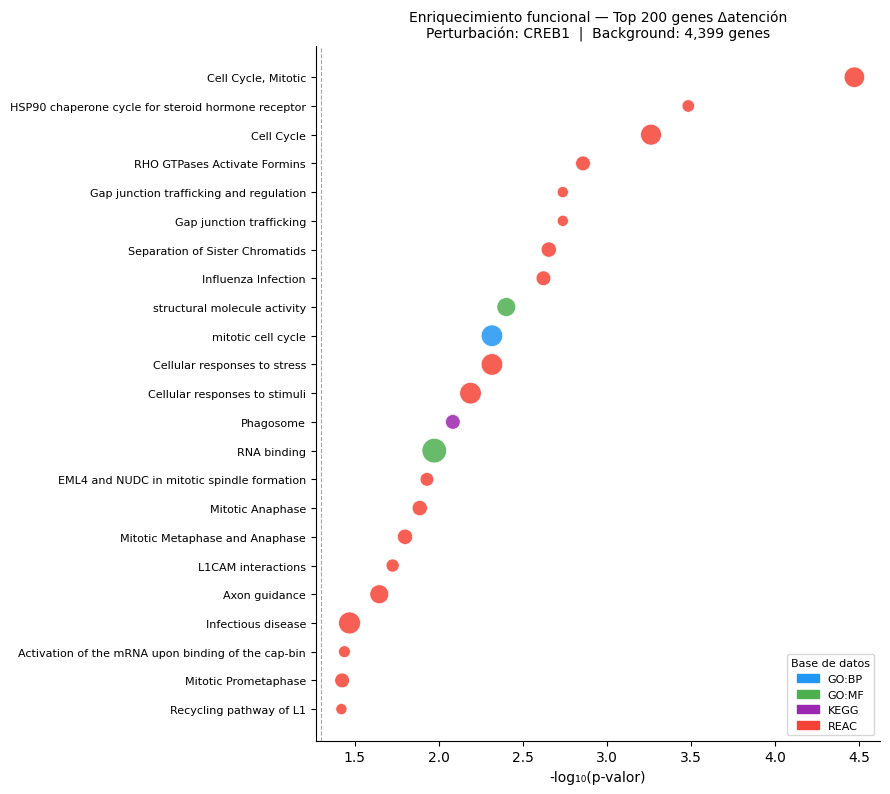

Figura guardada: enrichment_dotplot_CREB1.png


In [13]:
if not sig_df.empty:
    # Tomar los N términos más significativos para la figura
    N_TERMS_PLOT = min(25, len(sig_df))
    plot_df = (
        sig_df
        .sort_values("p_value")
        .head(N_TERMS_PLOT)
        .copy()
    )
    plot_df["-log10_pval"] = -np.log10(plot_df["p_value"].clip(lower=1e-300))

    # Paleta de colores por fuente
    source_colors = {
        "GO:BP": "#2196F3",
        "GO:MF": "#4CAF50",
        "GO:CC": "#FF9800",
        "KEGG":  "#9C27B0",
        "REAC":  "#F44336",
    }
    colors_dot = [source_colors.get(s, "gray") for s in plot_df["source"]]

    fig, ax = plt.subplots(figsize=(9, max(5, N_TERMS_PLOT * 0.35)))

    scatter = ax.scatter(
        plot_df["-log10_pval"],
        range(len(plot_df)),
        c=colors_dot,
        s=plot_df["intersection_size"] * 8,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.5,
    )

    ax.set_yticks(range(len(plot_df)))
    ax.set_yticklabels(
        [f"{row['name'][:50]}" for _, row in plot_df.iterrows()],
        fontsize=8
    )
    ax.set_xlabel("-log₁₀(p-valor)", fontsize=10)
    ax.set_title(
        f"Enriquecimiento funcional — Top {TOP_K_GENES} genes Δatención\n"
        f"Perturbación: {GEN_PERTURBADO}  |  Background: {len(background_genes):,} genes",
        fontsize=10
    )

    # Línea de significancia p=0.05
    ax.axvline(x=-np.log10(0.05), color="gray", linestyle="--",
               linewidth=0.8, alpha=0.7, label="p = 0.05")

    # Leyenda de fuentes
    source_patches = [
        mpatches.Patch(color=c, label=s)
        for s, c in source_colors.items()
        if s in plot_df["source"].values
    ]
    ax.legend(handles=source_patches, title="Base de datos",
              loc="lower right", fontsize=8, title_fontsize=8)

    ax.invert_yaxis()
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    fig_name = f"enrichment_dotplot_{GEN_PERTURBADO}.png"
    plt.savefig(fig_name, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figura guardada: {fig_name}")
else:
    print("Sin términos significativos para visualizar.")

## 13. Tabla resumen de enriquecimiento

In [14]:
if not sig_df.empty:
    # Tabla completa ordenada por p-valor
    tabla_enrich = (
        sig_df[
            ["source", "native", "name", "term_size",
             "query_size", "intersection_size", "p_value"]
        ]
        .sort_values("p_value")
        .reset_index(drop=True)
    )
    tabla_enrich["p_value"] = tabla_enrich["p_value"].map("{:.2e}".format)
    tabla_enrich.columns = [
        "Fuente", "ID término", "Nombre", "Tamaño término",
        "Genes query", "Genes solapantes", "p-valor"
    ]

    # Guardar CSV
    csv_name = f"enrichment_table_{GEN_PERTURBADO}.csv"
    tabla_enrich.to_csv(csv_name, index=False)
    print(f"Tabla guardada: {csv_name}")
    print(f"\nTotal de términos significativos: {len(tabla_enrich)}")
    print("\nDistribución por base de datos:")
    print(tabla_enrich["Fuente"].value_counts().to_string())
    print("\nTop 15 términos:")
    display(tabla_enrich.head(15))
else:
    print("Sin resultados de enriquecimiento.")

Tabla guardada: enrichment_table_CREB1.csv

Total de términos significativos: 23

Distribución por base de datos:
Fuente
REAC     19
GO:MF     2
GO:BP     1
KEGG      1

Top 15 términos:


,Fuente,ID término,Nombre,Tamaño término,Genes query,Genes solapantes,p-valor
0,REAC,REAC:R-HSA-69278,"Cell Cycle, Mitotic",156,170,27,3.39e-05
1,REAC,REAC:R-HSA-3371497,HSP90 chaperone cycle for steroid hormone rece...,21,170,10,3.29e-04
2,REAC,REAC:R-HSA-1640170,Cell Cycle,188,170,28,5.48e-04
3,REAC,REAC:R-HSA-5663220,RHO GTPases Activate Formins,51,170,14,1.39e-03
4,REAC,REAC:R-HSA-157858,Gap junction trafficking and regulation,14,170,8,1.83e-03
5,REAC,REAC:R-HSA-190828,Gap junction trafficking,14,170,8,1.83e-03
6,REAC,REAC:R-HSA-2467813,Separation of Sister Chromatids,61,170,15,2.22e-03
7,REAC,REAC:R-HSA-168255,Influenza Infection,53,170,14,2.38e-03
8,GO:MF,GO:0005198,structural molecule activity,145,170,23,3.96e-03
9,GO:BP,GO:0000278,mitotic cell cycle,233,170,30,4.83e-03


## 14. Resumen final del pipeline

In [15]:
print("╔" + "═" * 58 + "╗")
print(f"║  RESUMEN PIPELINE — Perturbación: {GEN_PERTURBADO:<22}║")
print("╠" + "═" * 58 + "╣")
print(f"║  Células ctrl analizadas      : {metrics['n_ctrl_cells']:<26}║")
print(f"║  Células perturbadas          : {metrics['n_pert_cells']:<26}║")
print(f"║  Genes HVG analizados         : {metrics['n_genes_total']:<26}║")
print(f"║  Background enriquecimiento   : {len(background_genes):<26}║")
print("╠" + "═" * 58 + "╣")
print(f"║  Pearson global (ctrl vs pert): r = {metrics['pearson_global']:<22}║")
print(f"║  Pearson top-{TOP_K_GENES} genes       : r = {metrics['pearson_top_k']:<22}║")
print(f"║  Pearson resto genes          : r = {metrics['pearson_rest']:<22}║")
print("╠" + "═" * 58 + "╣")
print(f"║  Top 10 genes por Δatención:")
for i, (g, s) in enumerate(df_topk.head(10).items(), 1):
    marker = "*" if g == GEN_PERTURBADO else " "
    line = f"║   {i:2d}.{marker}{g:<12} Δatención = {s:.4f}"
    print(line + " " * (59 - len(line)) + "║")
print("╠" + "═" * 58 + "╣")
n_terms = len(sig_df) if not sig_df.empty else 0
print(f"║  Términos enriquecimiento sig.: {n_terms:<26}║")
if not sig_df.empty:
    top3 = sig_df.sort_values("p_value").head(3)
    for _, row in top3.iterrows():
        term_str = f"[{row['source']}] {row['name'][:30]}"
        line = f"║     {term_str}"
        print(line + " " * (59 - len(line)) + "║")
print("╚" + "═" * 58 + "╝")

╔══════════════════════════════════════════════════════════╗
║  RESUMEN PIPELINE — Perturbación: CREB1                 ║
╠══════════════════════════════════════════════════════════╣
║  Células ctrl analizadas      : 24263                     ║
║  Células perturbadas          : 472                       ║
║  Genes HVG analizados         : 2000                      ║
║  Background enriquecimiento   : 4399                      ║
╠══════════════════════════════════════════════════════════╣
║  Pearson global (ctrl vs pert): r = 0.9763000011444092    ║
║  Pearson top-200 genes       : r = 0.9810000061988831    ║
║  Pearson resto genes          : r = 0.9763000011444092    ║
╠══════════════════════════════════════════════════════════╣
║  Top 10 genes por Δatención:
║    1. P2RX1        Δatención = 0.0000                    ║
║    2. C11orf96     Δatención = 0.0000                    ║
║    3. GFY          Δatención = 0.0000                    ║
║    4. GYPA         Δatención = 0.0000          